In [1]:
# Import libraries
import numpy as np
import pandas as pd
from filterpy.kalman import KalmanFilter
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
# Load CSV data and select columns
# TODO: Replace 'your_file.csv' with your CSV path
csv_file_1= 'SBS_ptns_2.csv'
update_csv = pd.read_csv(csv_file_1)

# Display available columns
print("Available columns:")
print(update_csv.columns.tolist())
print("\nFirst few rows:")
print(update_csv.head())

Available columns:
['Timestamp', 'Sonar_Distance_1', 'Confidence_1', 'Sonar_Distance_2', 'Confidence_2', 'Sonar_Distance_3', 'Rezero_timestamp']

First few rows:
      Timestamp  Sonar_Distance_1  Confidence_1  Sonar_Distance_2  \
0  1.739939e+09             12638           100              8625   
1  1.739939e+09             12506           100              8465   
2  1.739939e+09             12518           100              8298   
3  1.739939e+09             12504           100              8130   
4  1.739939e+09             12525           100              7977   

   Confidence_2  Sonar_Distance_3  Rezero_timestamp  
0           100                 0           0.00000  
1           100                 0           0.64303  
2           100                 0           1.28587  
3           100                 0           1.92923  
4           100                 0           2.56681  


Converting dimensions to metres and keeping sway readings relative

In [3]:
update_csv["Sonar_Distance_1"]=update_csv["Sonar_Distance_1"]/1000.0
update_csv["Sonar_Distance_2"]=update_csv["Sonar_Distance_2"]/1000.0
update_csv['Sonar_Distance_1']=update_csv['Sonar_Distance_1']-update_csv['Sonar_Distance_1'][0]

In [4]:
# Load CSV data and select columns
# TODO: Replace 'your_file.csv' with your CSV path
csv_file_2= 'FLS_ptns_2.csv'
predict_csv = pd.read_csv(csv_file_2)

# Display available columns
print("Available columns:")
print(predict_csv.columns.tolist())
print("\nFirst few rows:")
print(predict_csv.head())

Available columns:
['Unnamed: 0', 'Time', 'Pose_X', 'Pose_Y', 'Rezeroed_timestamps']

First few rows:
   Unnamed: 0          Time  Pose_X    Pose_Y  Rezeroed_timestamps
0           0  1.739968e+09  0.0000  6.022083                  0.0
1           1  1.739968e+09  0.0000  6.143333                  0.1
2           2  1.739968e+09 -0.0808  6.345417                  0.2
3           3  1.739968e+09  0.0808  6.345417                  0.3
4           4  1.739968e+09 -0.3232  6.062500                  0.4


In [5]:
predict_csv["Pose_X"]=predict_csv["Pose_X"]-predict_csv["Pose_X"][0]

In [6]:
predict_csv_modified=predict_csv
predict_csv_modified["Pose_X"]=-0.2-predict_csv["Pose_X"]
predict_csv_modified["Pose_Y"]=1+predict_csv["Pose_Y"]

In [7]:
def vel_calc(df,x_col="Pose_X",y_col="Pose_Y",time_col="Rezeroed_timestamps"):
    df['vx'] = df[x_col].diff() / df[time_col].diff()
    df['vy'] = df[y_col].diff() / df[time_col].diff()
    df['vx'].fillna(0, inplace=True)  # Fill NaN values with 0 for the first row
    df['vy'].fillna(0, inplace=True)  # Fill NaN values with 0 for the first row
    return df
predict_csv = vel_calc(predict_csv_modified)
update_csv = vel_calc(update_csv,x_col="Sonar_Distance_1",y_col="Sonar_Distance_2",time_col="Rezero_timestamp")

/tmp/ipykernel_3878/629191227.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['vx'].fillna(0, inplace=True)  # Fill NaN values with 0 for the first row
/tmp/ipykernel_3878/629191227.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [8]:
predict_csv_modified

,Unnamed: 0,Time,Pose_X,Pose_Y,Rezeroed_timestamps,vx,vy
0,0,1.739968e+09,-0.2000,7.022083,0.0,0.000000,0.000000
1,1,1.739968e+09,-0.2000,7.143333,0.1,0.000000,1.212498
2,2,1.739968e+09,-0.1192,7.345417,0.2,0.808001,2.020835
3,3,1.739968e+09,-0.2808,7.345417,0.3,-1.616002,0.000000
4,4,1.739968e+09,0.1232,7.062500,0.4,4.039994,-2.829163
...,...,...,...,...,...,...,...
314,314,1.739968e+09,-0.4424,1.525417,31.4,0.807999,0.000000
315,315,1.739968e+09,-0.6040,1.525417,31.5,-1.616002,0.000000
316,316,1.739968e+09,-0.4828,1.525417,31.6,1.211998,0.000000
317,317,1.739968e+09,-0.9272,1.525417,31.7,-4.444004,0.000000


In [9]:
gt=pd.read_csv("GT_ptns.csv")
gt.head()

,Unnamed: 0,AUV_x_pixels,AUV_y_pixels,AUV_x_real,AUV_y_real
0,0,308,520,3.08,1.56
1,1,309,520,3.09,1.56
2,2,309,520,3.09,1.56
3,3,310,520,3.10,1.56
4,4,310,520,3.10,1.56


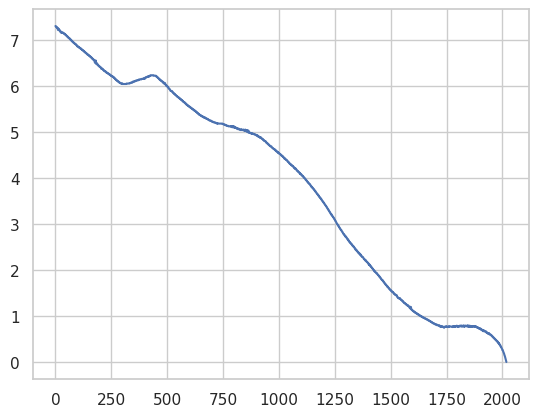

In [10]:
plt.plot(-(gt["AUV_x_real"]-gt["AUV_x_real"][len(gt)-1]))

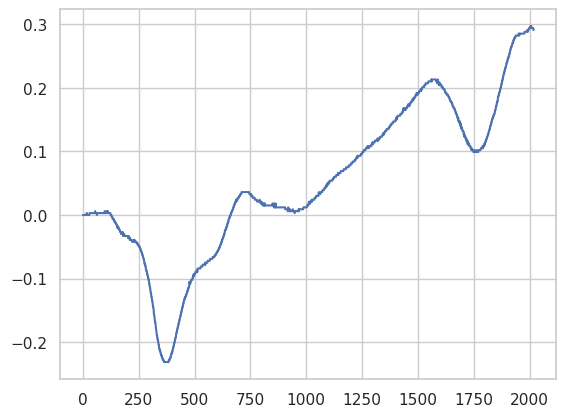

In [11]:
plt.plot(-(gt["AUV_y_real"]-gt["AUV_y_real"][0]))

In [12]:


num_steps = 1000
dt = 32.0 / num_steps

kf = KalmanFilter(dim_x=4, dim_z=4)

# Constant velocity model
kf.F = np.array([
    [1., 0., dt, 0.],
    [0., 1., 0., dt],
    [0., 0., 1., 0.],
    [0., 0., 0., 1.]
])

# Measurement matrix (sensor gives full state)
kf.H = np.eye(4)

# Process noise
kf.Q = np.eye(4) * 0.0001

# Initial covariance
kf.P = np.eye(4) * 10.

# Initial state
kf.x = np.zeros((4,1))

print("Kalman Filter initialized")


Kalman Filter initialized


In [13]:
R_sbs = np.diag([0.01,0.01,0.01,0.01])
R_fls = np.diag([1,1,1,1])


In [14]:
time_iterator = np.linspace(0, 32, num_steps)

j = 0  # SBS index
k = 0  # FLS index

results = []

for time_stamp in time_iterator:

    # -----------------------------
    # Prediction step
    # -----------------------------
    kf.predict()

    # -----------------------------
    # SBS update
    # -----------------------------
    
    if j < len(update_csv):
        if time_stamp >= update_csv.iloc[j]["Rezero_timestamp"]:

            z_sbs = np.array([
                [update_csv.iloc[j]["Sonar_Distance_1"]],
                [update_csv.iloc[j]["Sonar_Distance_2"]],
                [update_csv.iloc[j]["vx"]],
                [update_csv.iloc[j]["vy"]]
            ])

            kf.update(z_sbs, R=R_sbs)
            j += 1

    # -----------------------------
    # FLS update
    # -----------------------------
    
    if k < len(predict_csv):
        if time_stamp >= predict_csv_modified.iloc[k]["Rezeroed_timestamps"]:

            z_fls = np.array([
                [predict_csv_modified.iloc[k]["Pose_X"]],
                [predict_csv_modified.iloc[k]["Pose_Y"]],
                [predict_csv_modified.iloc[k]["vx"]],
                [predict_csv_modified.iloc[k]["vy"]]
            ])

            kf.update(z_fls, R=R_fls)
            k += 1
    
    results.append(kf.x.flatten())


In [15]:
sns.set_style("whitegrid")
sns.set_context("paper")
palette = sns.color_palette("Set2")
markers = ['o', 's', '^',"*"]
sns.despine()

# --- Thesis-level font settings (bold legends, consistent sizes) ---
plt.rcParams.update({
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 12,
    'legend.edgecolor': 'black'
})

<Figure size 640x480 with 0 Axes>

TypeError: list indices must be integers or slices, not tuple

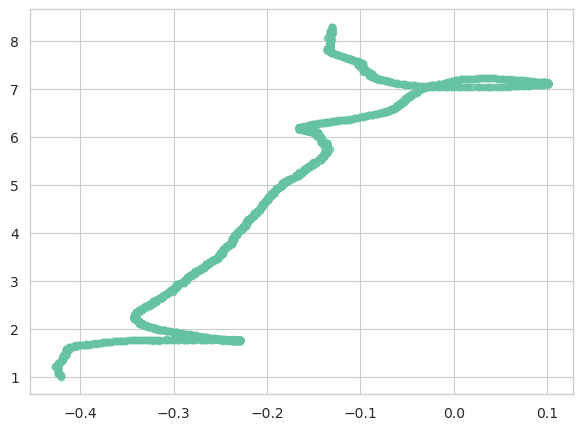

In [16]:
plt.figure(figsize=(7,5))
plt.scatter((-0.13+gt["AUV_y_real"]-gt["AUV_y_real"][0]),1-(gt["AUV_x_real"]-gt["AUV_x_real"][len(gt)-1]),label="GT",color=palette[0], marker=markers[0],alpha=0.7)
plt.scatter(results[:,0],results[:,1],label="Kalman Filter Estimate",color=palette[1], marker=markers[1],alpha=0.7)
plt.scatter(predict_csv_modified["Pose_X"],predict_csv_modified["Pose_Y"],label="FLS only",color=palette[2], marker=markers[2],alpha=0.7)
plt.scatter(update_csv["Sonar_Distance_1"],update_csv["Sonar_Distance_2"],label="SBS only",color=palette[3], marker=markers[3],alpha=0.7)
results=np.array(results)

plt.legend(loc='upper left')
#plt.xlabel("Sway (m)")
#plt.ylabel("Surge (m)")

plt.xlabel("Surge position (m)",fontsize=13, fontweight='bold')
plt.ylabel("Sway position (m)",fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')

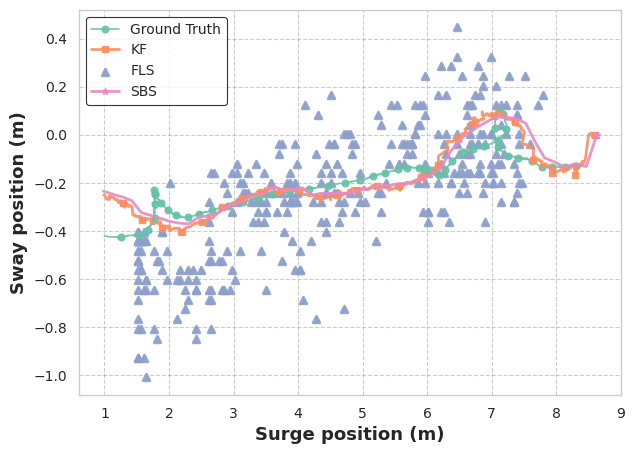

In [17]:
results = np.array(results)

plt.figure(figsize=(7,5))

plt.plot(
    1-np.array(gt["AUV_x_real"]-gt["AUV_x_real"][len(gt)-1]),
    (-0.13+np.array(gt["AUV_y_real"]-gt["AUV_y_real"][0])),
    label="Ground Truth", color=palette[0], marker=markers[0], alpha=0.9,markevery=40
)

plt.plot(
    results[:,1], results[:,0],
    label="KF",
    color=palette[1], marker=markers[1],linewidth=2,alpha=0.9,markevery=40
)

plt.scatter(
    predict_csv_modified["Pose_Y"],
    predict_csv_modified["Pose_X"],
    label="FLS",
    color=palette[2], marker=markers[2], alpha=0.9,linewidth=2
)

plt.plot(
    np.array(update_csv["Sonar_Distance_2"]),
    np.array(update_csv["Sonar_Distance_1"]),
    label="SBS",
    color=palette[3], marker=markers[3], alpha=0.9,linewidth=2,markevery=40
)

plt.legend(loc='upper left')

plt.xlabel("Surge position (m)", fontsize=13, fontweight='bold')
plt.ylabel("Sway position (m)", fontsize=13, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.4, color='gray')


In [23]:
# --- Compute errors w.r.t. GT for each dataset ---
gt_x = -0.13 + gt["AUV_y_real"] - gt["AUV_y_real"].iloc[0]
gt_y = 1 - (gt["AUV_x_real"] - gt["AUV_x_real"].iloc[-1])

def axis_errors(xs, ys, gt_x, gt_y):
    # For each (x, y), find the closest GT point and return axis errors
    pts = np.vstack((gt_x.values, gt_y.values)).T
    err_xs = []
    err_ys = []
    for x, y in zip(xs, ys):
        d2 = (pts[:,0] - x)**2 + (pts[:,1] - y)**2
        idx = np.argmin(d2)
        err_xs.append(pts[idx,0] - x)
        err_ys.append(pts[idx,1] - y)
    return np.array(err_xs), np.array(err_ys)

def metrics(errs):
    mean = np.mean(errs)
    rmse = np.sqrt(np.mean(errs**2))
    var = np.var(errs)
    return mean, rmse, var

# FLS errors
err_fls_x, err_fls_y = axis_errors(predict_csv_modified["Pose_X"].values, predict_csv_modified["Pose_Y"].values, gt_x, gt_y)
# SBS errors
err_sbs_x, err_sbs_y = axis_errors(update_csv["Sonar_Distance_1"].values, update_csv["Sonar_Distance_2"].values, gt_x, gt_y)
# KF errors
err_kf_x, err_kf_y = axis_errors(results[:,0], results[:,1], gt_x, gt_y)

m_fls_x = metrics(err_fls_x)
m_fls_y = metrics(err_fls_y)
m_sbs_x = metrics(err_sbs_x)
m_sbs_y = metrics(err_sbs_y)
m_kf_x = metrics(err_kf_x)
m_kf_y = metrics(err_kf_y)

print(f"FLS X: mean={m_fls_x[0]:.4f} m, RMSE={m_fls_x[1]:.4f} m, Var={m_fls_x[2]:.6f}")
print(f"FLS Y: mean={m_fls_y[0]:.4f} m, RMSE={m_fls_y[1]:.4f} m, Var={m_fls_y[2]:.6f}")
print(f"SBS X: mean={m_sbs_x[0]:.4f} m, RMSE={m_sbs_x[1]:.4f} m, Var={m_sbs_x[2]:.6f}")
print(f"SBS Y: mean={m_sbs_y[0]:.4f} m, RMSE={m_sbs_y[1]:.4f} m, Var={m_sbs_y[2]:.6f}")
print(f"KF  X: mean={m_kf_x[0]:.4f} m, RMSE={m_kf_x[1]:.4f} m, Var={m_kf_x[2]:.6f}")
print(f"KF  Y: mean={m_kf_y[0]:.4f} m, RMSE={m_kf_y[1]:.4f} m, Var={m_kf_y[2]:.6f}")

FLS X: mean=0.0442 m, RMSE=0.1966 m, Var=0.036680
FLS Y: mean=-0.0022 m, RMSE=0.0348 m, Var=0.001208
SBS X: mean=-0.0178 m, RMSE=0.0664 m, Var=0.004095
SBS Y: mean=-0.0113 m, RMSE=0.0554 m, Var=0.002940
KF  X: mean=-0.0120 m, RMSE=0.0629 m, Var=0.003809
KF  Y: mean=-0.0065 m, RMSE=0.0433 m, Var=0.001829
